1. Setup & Imports
2. Stage-1 Training (CNN + XLM-R)
3. Stage-2 Training (CNN + XLM-R)
4. Runtime Pipeline
   ├─ Fetch Gmail
   ├─ Preprocess
   ├─ Stage-1 Inference
   ├─ Stage-1.5 Authenticity Filter
   ├─ Stage-2 Intent Inference
5. Final Output


In [1]:
# ====== SETUP ======
!pip install -q transformers datasets evaluate accelerate
!pip install -q tensorflow torch joblib google-api-python-client google-auth google-auth-oauthlib langdetect

import os, re, json, base64, pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 23.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)


In [3]:
# Run this cell first (may take some minutes)
!pip install -q --upgrade pip
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib
!pip install -q transformers datasets evaluate accelerate
!pip install -q torch torchvision torchaudio       # Colab usually already has compatible torch
!pip install -q tensorflow                         # for Keras CNN
!pip install -q google-auth google-auth-oauthlib google-api-python-client


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.3 MB/s eta 0:00:00


In [4]:
# ====== STAGE 1 TRAINING ======
DATA_PATH = "/content/Stage1_ideal_balanced_final.csv"
MODELS_DIR = "/content/stage1_models"
os.makedirs(MODELS_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)

TEXT_COL = "preprocessed_text"
LABEL_COL = "category"

le = LabelEncoder()
df["label"] = le.fit_transform(df[LABEL_COL])
joblib.dump(le, f"{MODELS_DIR}/label_encoder_stage1.joblib")

X_train, X_test, y_train, y_test = train_test_split(
    df[TEXT_COL], df["label"], stratify=df["label"], test_size=0.2, random_state=42
)

print("Stage-1 labels:", list(le.classes_))


Stage-1 labels: ['job_agency_spam', 'job_related', 'non_job', 'promotional']


In [5]:
DATA_PATH = "/content/Stage1_ideal_balanced_final.csv"
df_stage1 = pd.read_csv(DATA_PATH)

# Fix typo if exists
df_stage1["category"] = df_stage1["category"].replace("non_nob", "non_job")

print(df_stage1.shape)
df_stage1.head()


(5956, 4)


,Sender,Subject,preprocessed_text,category
0,"""Bäckerei Dreißig GmbH & Co. KG"" <noreply@inde...",Neuigkeiten zu Ihrer Bewerbung von Bäckerei Dr...,neuigkeiten zu ihrer bewerbung von baeckerei d...,job_agency_spam
1,"""bewerbung@centrovital-berlin.de"" <info@hoga.s...",Nachricht von bewerbung@centrovital-berlin.de:...,nachricht von email : ihre bewerbung als commi...,job_agency_spam
2,"""hr.berlin@hilton.com"" <info@hoga.stepstone.com>",Nachricht von hr.berlin@hilton.com: Ihre Bewer...,nachricht von email : ihre bewerbung als food ...,job_agency_spam
3,"""hr@hotelzoo.de"" <info@hoga.stepstone.com>",Nachricht von hr@hotelzoo.de: Vielen Dank für ...,nachricht von email : vielen dank fuer deine b...,job_agency_spam
4,"""m.wilkesmann@filmhotel.de"" <info@hoga.stepsto...",Nachricht von m.wilkesmann@filmhotel.de: Ihre ...,nachricht von email : ihre bewerbung im hollyw...,job_agency_spam



=== STAGE 1 EDA ===
Dataset shape: (5956, 4)


,Sender,Subject,preprocessed_text,category
0,"""Bäckerei Dreißig GmbH & Co. KG"" <noreply@inde...",Neuigkeiten zu Ihrer Bewerbung von Bäckerei Dr...,neuigkeiten zu ihrer bewerbung von baeckerei d...,job_agency_spam
1,"""bewerbung@centrovital-berlin.de"" <info@hoga.s...",Nachricht von bewerbung@centrovital-berlin.de:...,nachricht von email : ihre bewerbung als commi...,job_agency_spam
2,"""hr.berlin@hilton.com"" <info@hoga.stepstone.com>",Nachricht von hr.berlin@hilton.com: Ihre Bewer...,nachricht von email : ihre bewerbung als food ...,job_agency_spam
3,"""hr@hotelzoo.de"" <info@hoga.stepstone.com>",Nachricht von hr@hotelzoo.de: Vielen Dank für ...,nachricht von email : vielen dank fuer deine b...,job_agency_spam
4,"""m.wilkesmann@filmhotel.de"" <info@hoga.stepsto...",Nachricht von m.wilkesmann@filmhotel.de: Ihre ...,nachricht von email : ihre bewerbung im hollyw...,job_agency_spam


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5956 entries, 0 to 5955
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sender             5956 non-null   object
 1   Subject            5949 non-null   object
 2   preprocessed_text  5952 non-null   object
 3   category           5956 non-null   object
dtypes: object(4)
memory usage: 186.3+ KB

Missing values:


,0
Sender,0
Subject,7
preprocessed_text,4
category,0


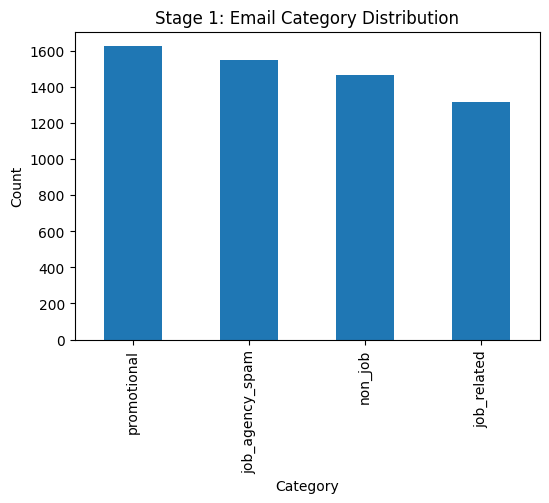

<Figure size 700x400 with 0 Axes>

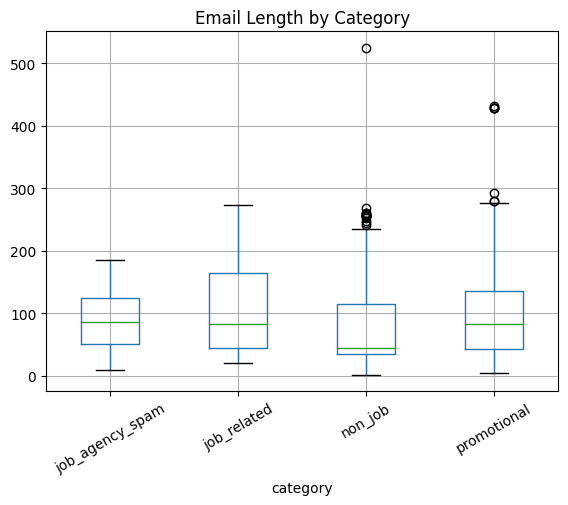

category         Sender                                                    
job_agency_spam  XING Jobs <jobs@mail.xing.com>                                192
                 Stepstone Daily Jobs <info@jobagent.stepstone.de>             180
                 LinkedIn Job Alerts <jobalerts-noreply@linkedin.com>          158
                 Hotelcareer <info@email.hotelcareer.de>                       141
                 Emma Jacobs from Stepstone <express@jobagent.stepstone.de>     97
job_related      DHL Group <ihrebewerbung@deutschepost.de>                     125
                 Amrita CIR <cir_amrita@haveloc.com>                           115
                 Recruiting <noreply@jobs.amazon.com>                           62
                 SPORTFIVE Eventjobs <events@jobs.sportfive.com>                43
                 jobvalley <no-reply@jobvalley.com>                             27
non_job          Temu <temu@eu.temuemail.com>                                  108
                 "WG-Gesucht.de" <webmaster@wg-gesucht.de>                      87
                 Pinterest <recommendations@discover.pinterest.com>             79
                 Netflix <info@members.netflix.com>                             65
                 MSN Daily <microsoft.start@email2.microsoft.com>               60
promotional      ship-confirm@ajio.com                                         175
                 Bharat Chaudhary <bharat@bharatingermany.com>                 137
                 Tata CLiQ Fashion <tatacliq@mall.tatacliq.com>                128
                 Amazon A to Z <notifications@atoz.amazon.work>                 85
                 Tira Beauty <noreply@updates.tirabeauty.com>                   63
Name: count, dtype: int64

In [6]:
# ====== EDA: STAGE 1 ======
assert "category" in df_stage1.columns, "Not Stage 1 data"

print("\n=== STAGE 1 EDA ===")

print("Dataset shape:", df_stage1.shape)
display(df_stage1.head())
df_stage1.info()

print("\nMissing values:")
display(df_stage1.isna().sum())

# Category distribution
plt.figure(figsize=(6,4))
df_stage1["category"].value_counts().plot(kind="bar")
plt.title("Stage 1: Email Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

# Text length
df_stage1["text_length"] = df_stage1["preprocessed_text"].astype(str).str.split().apply(len)
plt.figure(figsize=(7,4))
df_stage1.boxplot(column="text_length", by="category", rot=30)
plt.title("Email Length by Category")
plt.suptitle("")
plt.show()

# Sender analysis

display(
    df_stage1.groupby("category")["Sender"]
    .value_counts()
    .groupby(level=0)
    .head(5)
)


In [7]:
df = pd.read_csv(DATA_PATH)
display(df.head())

# auto-detect
possible_text_cols = ['body','text','email_body','message','clean_body','text_model','text_clean','preprocessed_text']
possible_label_cols = ['label','category','target','stage1_label','class']

text_col = None; label_col = None
for c in df.columns:
    if c.lower() in possible_text_cols: text_col = c
    if c.lower() in possible_label_cols: label_col = c

if text_col is None:
    str_cols = [c for c in df.columns if df[c].dtype == 'object']
    avg_lens = {c: df[c].dropna().astype(str).map(len).mean() for c in str_cols}
    text_col = max(avg_lens, key=avg_lens.get)

if label_col is None:
    for c in df.columns[::-1]:
        if df[c].nunique() < 200 and df[c].dtype == 'object' and c!=text_col:
            label_col = c; break
    if label_col is None:
        label_col = df.columns[-1]

print("Using text column:", text_col)
print("Using label column:", label_col)


,Sender,Subject,preprocessed_text,category
0,"""Bäckerei Dreißig GmbH & Co. KG"" <noreply@inde...",Neuigkeiten zu Ihrer Bewerbung von Bäckerei Dr...,neuigkeiten zu ihrer bewerbung von baeckerei d...,job_agency_spam
1,"""bewerbung@centrovital-berlin.de"" <info@hoga.s...",Nachricht von bewerbung@centrovital-berlin.de:...,nachricht von email : ihre bewerbung als commi...,job_agency_spam
2,"""hr.berlin@hilton.com"" <info@hoga.stepstone.com>",Nachricht von hr.berlin@hilton.com: Ihre Bewer...,nachricht von email : ihre bewerbung als food ...,job_agency_spam
3,"""hr@hotelzoo.de"" <info@hoga.stepstone.com>",Nachricht von hr@hotelzoo.de: Vielen Dank für ...,nachricht von email : vielen dank fuer deine b...,job_agency_spam
4,"""m.wilkesmann@filmhotel.de"" <info@hoga.stepsto...",Nachricht von m.wilkesmann@filmhotel.de: Ihre ...,nachricht von email : ihre bewerbung im hollyw...,job_agency_spam


Using text column: preprocessed_text
Using label column: category


In [8]:
# Convert train/test splits to text variables (REQUIRED)
X_train_text = X_train.astype(str)
X_test_text  = X_test.astype(str)

print("X_train_text ready:", X_train_text.shape)
print("X_test_text ready :", X_test_text.shape)
# Create label_names from the fitted LabelEncoder
label_names = list(le.classes_)

print("Label names:", label_names)
print("Number of classes:", len(label_names))


X_train_text ready: (4764,)
X_test_text ready : (1192,)
Label names: ['job_agency_spam', 'job_related', 'non_job', 'promotional']
Number of classes: 4


In [9]:
# Keras CNN baseline
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from sklearn.metrics import accuracy_score

# Tokenizer & sequences
max_words = 30000
maxlen = 300

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=maxlen, padding='post', truncating='post')

num_classes = len(label_names)
embed_dim = 128

# Model
inputs = layers.Input(shape=(maxlen,))
x = layers.Embedding(input_dim=max_words, output_dim=embed_dim, input_length=maxlen)(inputs)
conv_blocks = []
for k in [3,4,5]:
    c = layers.Conv1D(filters=128, kernel_size=k, activation='relu')(x)
    p = layers.GlobalMaxPooling1D()(c)
    conv_blocks.append(p)
x = layers.concatenate(conv_blocks) if len(conv_blocks)>1 else conv_blocks[0]
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
cnn_model = keras.Model(inputs, outputs)
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

# Train (Colab GPU will be used by TF if available)
history = cnn_model.fit(X_train_pad, y_train, validation_split=0.1, epochs=5, batch_size=64)

# Evaluate
y_pred_cnn = np.argmax(cnn_model.predict(X_test_pad), axis=1)
print("=== CNN classification report ===")
print(classification_report(y_test, y_pred_cnn, target_names=label_names))
print("Accuracy:", accuracy_score(y_test, y_pred_cnn))

# Save model + tokenizer
cnn_model.save(os.path.join(MODELS_DIR, "keras_cnn_stage1.h5"))
with open(os.path.join(MODELS_DIR, "keras_tokenizer.json"), "w", encoding="utf-8") as f:
    f.write(tokenizer.to_json())
print("Saved Keras CNN and tokenizer to", MODELS_DIR)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 128)  │  3,840,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 298, 128)  │     49,280 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 297, 128)  │     65,664 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 296, 128)  │     82,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     49,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        516 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,086,788 (15.59 MB)

 Trainable params: 4,086,788 (15.59 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 19s 198ms/step - accuracy: 0.5184 - loss: 1.1517 - val_accuracy: 0.8470 - val_loss: 0.4062
Epoch 2/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9069 - loss: 0.2914 - val_accuracy: 0.9413 - val_loss: 0.2061
Epoch 3/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9842 - loss: 0.0876 - val_accuracy: 0.9518 - val_loss: 0.1910
Epoch 4/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9945 - loss: 0.0347 - val_accuracy: 0.9539 - val_loss: 0.1909
Epoch 5/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9963 - loss: 0.0188 - val_accuracy: 0.9497 - val_loss: 0.1977
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step


=== CNN classification report ===
                 precision    recall  f1-score   support

job_agency_spam       0.99      0.99      0.99       310
    job_related       0.99      0.99      0.99       264
        non_job       0.89      0.96      0.92       293
    promotional       0.95      0.89      0.92       325

       accuracy                           0.95      1192
      macro avg       0.95      0.96      0.95      1192
   weighted avg       0.95      0.95      0.95      1192

Accuracy: 0.9530201342281879
Saved Keras CNN and tokenizer to /content/stage1_models


In [10]:
y_pred_cnn = np.argmax(cnn_model.predict(X_test_pad), axis=1)
print(classification_report(y_test, y_pred_cnn, target_names=label_names))


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
                 precision    recall  f1-score   support

job_agency_spam       0.99      0.99      0.99       310
    job_related       0.99      0.99      0.99       264
        non_job       0.89      0.96      0.92       293
    promotional       0.95      0.89      0.92       325

       accuracy                           0.95      1192
      macro avg       0.95      0.96      0.95      1192
   weighted avg       0.95      0.95      0.95      1192



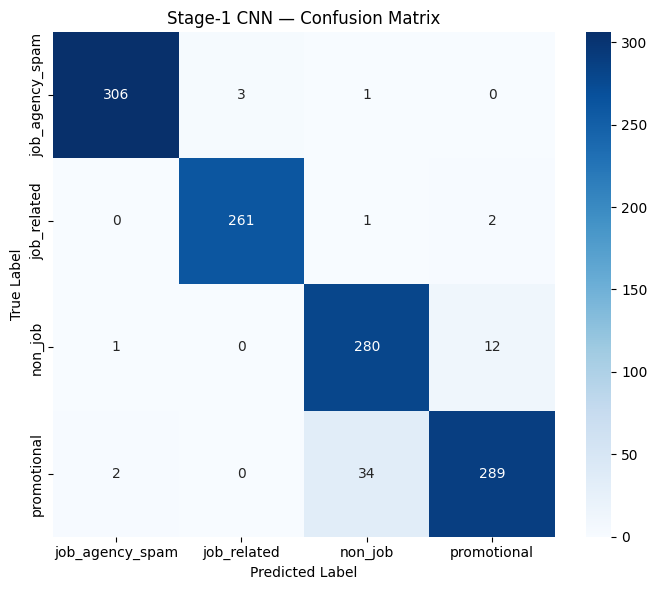

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Stage-1 CNN — Confusion Matrix")
plt.tight_layout()
plt.show()


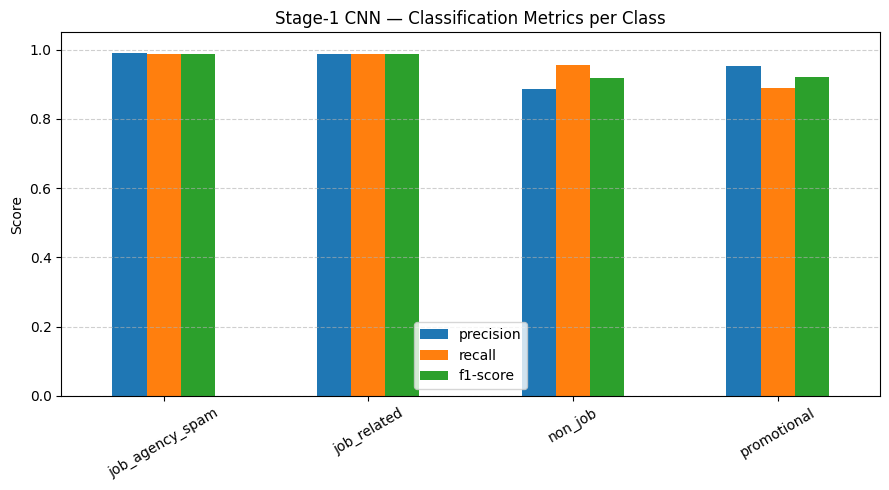

In [12]:
import pandas as pd
from sklearn.metrics import classification_report

# Convert classification report to DataFrame
report_dict = classification_report(
    y_test,
    y_pred_cnn,
    target_names=label_names,
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()

# Plot Precision, Recall, F1-score
metrics = ["precision", "recall", "f1-score"]

df_report.loc[label_names, metrics].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Stage-1 CNN — Classification Metrics per Class")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [13]:
# ---------- Store probability outputs (CRITICAL FOR ROC) ----------
cnn_probs_stage1 = cnn_model.predict(X_test_pad, verbose=0)

# Class predictions (for confusion matrix & report)
y_pred_cnn = np.argmax(cnn_probs_stage1, axis=1)


In [14]:
num_classes = cnn_probs_stage1.shape[1]

# Keep only samples whose labels are within model output range
valid_idx = y_test < num_classes

y_test_fixed = y_test[valid_idx]
cnn_probs_fixed = cnn_probs_stage1[valid_idx]

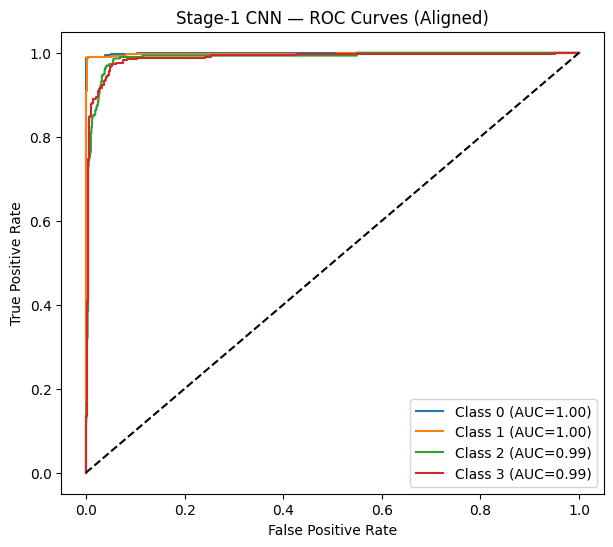

In [15]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Proper binarization
y_test_bin = label_binarize(
    y_test_fixed,
    classes=list(range(num_classes))
)

plt.figure(figsize=(7, 6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], cnn_probs_fixed[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Stage-1 CNN — ROC Curves (Aligned)")
plt.legend()
plt.show()


In [16]:
# Prepare HF datasets
from datasets import Dataset
from transformers import AutoTokenizer

MODEL_XLM = "xlm-roberta-base"
tokenizer_xlm = AutoTokenizer.from_pretrained(MODEL_XLM)

train_df = pd.DataFrame({'text': X_train_text, 'label': y_train})
eval_df  = pd.DataFrame({'text': X_test_text,  'label': y_test})

train_ds = Dataset.from_pandas(train_df)
eval_ds  = Dataset.from_pandas(eval_df)

def tokenize_fn(batch):
    return tokenizer_xlm(batch['text'], max_length=256, truncation=True, padding='max_length')

train_ds = train_ds.map(tokenize_fn, batched=True)
eval_ds  = eval_ds.map(tokenize_fn, batched=True)

# remove extra columns safely
cols_to_remove = [c for c in ['text','__index_level_0__'] if c in train_ds.column_names]
if cols_to_remove:
    train_ds = train_ds.remove_columns(cols_to_remove)
cols_to_remove_eval = [c for c in ['text','__index_level_0__'] if c in eval_ds.column_names]
if cols_to_remove_eval:
    eval_ds = eval_ds.remove_columns(cols_to_remove_eval)

# Set format to torch with available inputs
model_input_cols = [c for c in ['input_ids','attention_mask','token_type_ids'] if c in train_ds.column_names]
model_input_cols.append('label')
train_ds.set_format(type='torch', columns=model_input_cols)
eval_ds.set_format(type='torch', columns=model_input_cols)

print("Train columns:", train_ds.column_names)
print("Eval columns:", eval_ds.column_names)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/4764 [00:00<?, ? examples/s]

Map:   0%|          | 0/1192 [00:00<?, ? examples/s]

Train columns: ['label', 'input_ids', 'attention_mask']
Eval columns: ['label', 'input_ids', 'attention_mask']


In [17]:
# Fine-tune XLM-R with Trainer
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate, numpy as np
import torch

model_xlm = AutoModelForSequenceClassification.from_pretrained(MODEL_XLM, num_labels=num_classes)

training_args = TrainingArguments(
    output_dir=os.path.join(MODELS_DIR, "xlm_stage1_output"),
    eval_strategy="epoch",         # use eval_strategy (works with newer HF)
    save_strategy="epoch",
    per_device_train_batch_size=8,   # reduce to 4 if OOM
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": metric_acc.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": metric_f1.compute(predictions=preds, references=labels, average='macro')["f1"]
    }

trainer = Trainer(
    model=model_xlm,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    tokenizer=tokenizer_xlm,
    compute_metrics=compute_metrics,
)

# Start training (uncomment to run). Training will use colab GPU.
print("Starting XLM-R training... (this may take a while)")
trainer.train()   # <-- run training
# Save trained model + tokenizer
trainer.save_model(os.path.join(MODELS_DIR, "xlm_stage1"))
tokenizer_xlm.save_pretrained(os.path.join(MODELS_DIR, "xlm_stage1"))
print("Saved XLM-R model to", os.path.join(MODELS_DIR, "xlm_stage1"))

# Evaluation using trainer.predict to get detailed preds for sklearn report
preds_output = trainer.predict(eval_ds)
logits = preds_output.predictions
preds = np.argmax(logits, axis=-1)
print("=== XLM-R classification report ===")
print(classification_report(y_test, preds, target_names=label_names))
print("Accuracy:", accuracy_score(y_test, preds))


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


/tmp/ipython-input-943165229.py:32: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Starting XLM-R training... (this may take a while)


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: WARNING Invalid choice
wandb: Enter your choice:

...

 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


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: yasaswinidharmavarapu24 (yasaswinidharmavarapu24-brandenburgische-technische-univ) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.399100,0.426493,0.893456,0.893470
2,0.249600,0.441631,0.921980,0.923044
3,0.165700,0.324712,0.937919,0.939063


Saved XLM-R model to /content/stage1_models/xlm_stage1


=== XLM-R classification report ===
                 precision    recall  f1-score   support

job_agency_spam       0.98      0.97      0.98       310
    job_related       0.97      0.96      0.97       264
        non_job       0.89      0.93      0.91       293
    promotional       0.91      0.89      0.90       325

       accuracy                           0.94      1192
      macro avg       0.94      0.94      0.94      1192
   weighted avg       0.94      0.94      0.94      1192

Accuracy: 0.9379194630872483


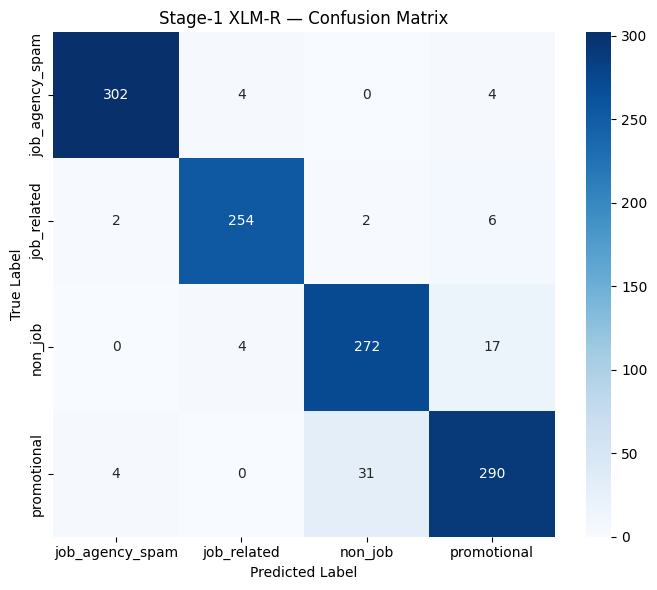

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Stage-1 XLM-R — Confusion Matrix")
plt.tight_layout()
plt.show()


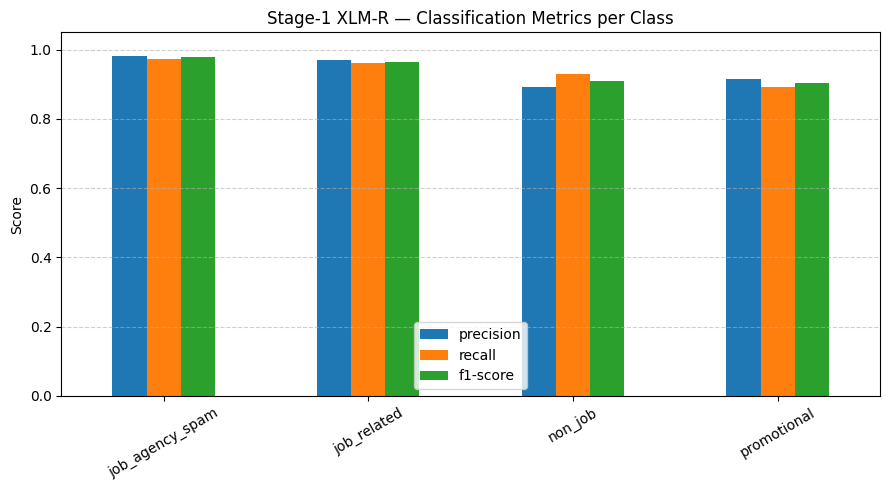

In [19]:
import pandas as pd
from sklearn.metrics import classification_report

# Convert report to DataFrame
report_dict = classification_report(
    y_test,
    preds,
    target_names=label_names,
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()

metrics = ["precision", "recall", "f1-score"]

df_report.loc[label_names, metrics].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Stage-1 XLM-R — Classification Metrics per Class")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


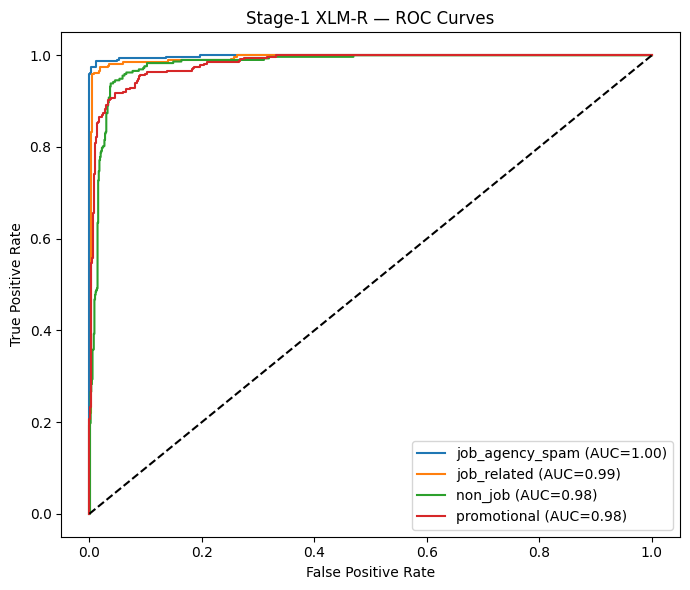

In [20]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

# Softmax probabilities
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()

# Binarize true labels
y_test_bin = label_binarize(
    y_test,
    classes=list(range(num_classes))
)

plt.figure(figsize=(7, 6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Stage-1 XLM-R — ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()


Stage2 Training

In [21]:
# ====== STAGE 2 TRAINING ======
df = pd.read_csv("stage2_final_clean.csv")

df = df[["preprocessed_text", "intent_label"]].rename(
    columns={"preprocessed_text": "text", "intent_label": "intent"}
)

le2 = LabelEncoder()
df["label"] = le2.fit_transform(df["intent"])
joblib.dump(le2, "label_encoder_stage2.joblib")

print("Stage-2 intent labels:", list(le2.classes_))


Stage-2 intent labels: ['acknowledgment', 'interview', 'next_step', 'rejection']



================ STAGE 2 EDA ================

Dataset shape: (400, 3)


,text,intent,label
0,re: kuechenhilfe (w/m/d) auf minijobbasis fuer...,rejection,3
1,re: kuechenhilfe (w/m/d) auf minijobbasis fuer...,rejection,3
2,re: kuechenhilfe (w/m/d) auf minijobbasis fuer...,rejection,3
3,"re: bewerbung – playstation promo am 19., 20.,...",next_step,2
4,"re: bewerbung – playstation promo am 19., 20.,...",next_step,2



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    400 non-null    object
 1   intent  400 non-null    object
 2   label   400 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 9.5+ KB


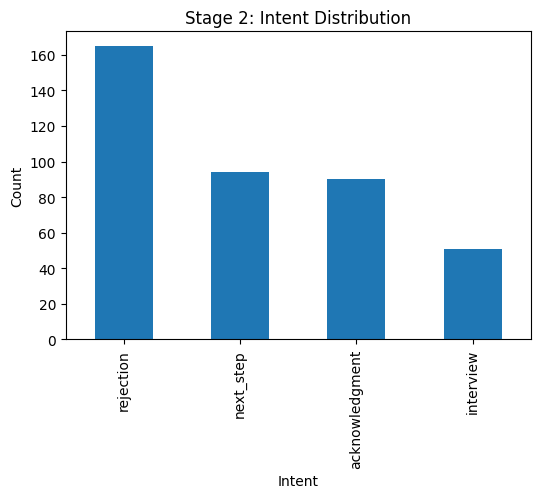

<Figure size 700x400 with 0 Axes>

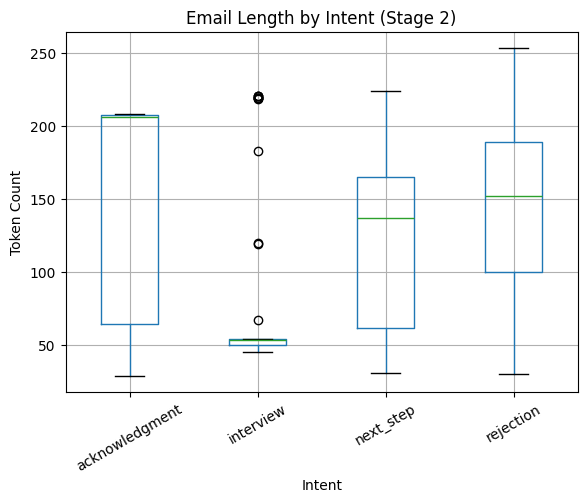


EDA INSIGHTS (Stage 2):
- Intent labels are highly imbalanced, with rejections dominating
- Different intents exhibit distinct structural patterns
- Rejection emails are formal and longer
- Interview emails are more conversational
These observations justify the use of contextual transformer models
and macro-averaged evaluation metrics



In [22]:
# =========================================================
# EDA – STAGE 2 (Job Email Intent Classification)
# =========================================================
# Purpose:
# - Analyze intent distribution and imbalance
# - Examine language vs intent behavior
# - Study structural differences across intents
# =========================================================

import matplotlib.pyplot as plt
import pandas as pd

print("\n================ STAGE 2 EDA ================\n")

# ---------- Dataset Overview ----------
print("Dataset shape:", df.shape)
display(df.head())
print("\nDataset info:")
df.info()

# ---------- Intent Distribution ----------
plt.figure(figsize=(6,4))
df["intent"].value_counts().plot(kind="bar")
plt.title("Stage 2: Intent Distribution")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.show()



# ---------- Text Length by Intent ----------
df["text_length"] = df["text"].astype(str).str.split().apply(len)

plt.figure(figsize=(7,4))
df.boxplot(column="text_length", by="intent", rot=30)
plt.title("Email Length by Intent (Stage 2)")
plt.suptitle("")
plt.xlabel("Intent")
plt.ylabel("Token Count")
plt.show()

print("""
EDA INSIGHTS (Stage 2):
- Intent labels are highly imbalanced, with rejections dominating
- Different intents exhibit distinct structural patterns
- Rejection emails are formal and longer
- Interview emails are more conversational
These observations justify the use of contextual transformer models
and macro-averaged evaluation metrics
""")


In [23]:
# ---------------- IMPORTS ----------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, BatchNormalization
)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# ---------------- LOAD DATA ----------------
df = pd.read_csv("stage2_final_clean.csv")

# Map correct columns
df = df[["preprocessed_text", "intent_label"]].rename(
    columns={
        "preprocessed_text": "text",
        "intent_label": "intent"
    }
).dropna()

print("Loaded Stage-2 data shape:", df.shape)
print("\nIntent distribution:")
print(df["intent"].value_counts())

# ---------------- LABEL ENCODING ----------------
le = LabelEncoder()
df["label"] = le.fit_transform(df["intent"])
num_labels = len(le.classes_)

print("\nEncoded intent classes:", list(le.classes_))

# Save label encoder
joblib.dump(le, "label_encoder_stage2.joblib")

# ---------------- TRAIN / VALIDATION SPLIT ----------------
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

# ---------------- TOKENIZATION ----------------
MAX_WORDS = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["text"])

X_train = pad_sequences(
    tokenizer.texts_to_sequences(train_df["text"]),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val = pad_sequences(
    tokenizer.texts_to_sequences(val_df["text"]),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

y_train = train_df["label"].values
y_val = val_df["label"].values

# ---------------- IMPROVED CNN MODEL ----------------
cnn_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=MAX_LEN
    ),

    Conv1D(128, 3, activation="relu", padding="same"),
    Conv1D(128, 5, activation="relu", padding="same"),
    Conv1D(128, 7, activation="relu", padding="same"),

    GlobalMaxPooling1D(),
    BatchNormalization(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(num_labels, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

# ---------------- TRAIN MODEL ----------------
cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=8,
    batch_size=32,
    verbose=1
)

# ---------------- EVALUATION ----------------
y_pred = np.argmax(cnn_model.predict(X_val), axis=1)

print("\n=== STAGE-2 CNN CLASSIFICATION REPORT ===")
print(classification_report(y_val, y_pred, target_names=le.classes_))

print("Accuracy:", accuracy_score(y_val, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

# ---------------- SAVE MODEL & TOKENIZER ----------------
cnn_model.save("cnn_stage2_intent.h5")

with open("cnn_stage2_tokenizer.json", "w", encoding="utf-8") as f:
    f.write(tokenizer.to_json())

print("\n✅ Improved Stage-2 CNN model, tokenizer, and label encoder saved.")


Loaded Stage-2 data shape: (400, 2)

Intent distribution:
intent
rejection         165
next_step          94
acknowledgment     90
interview          51
Name: count, dtype: int64

Encoded intent classes: ['acknowledgment', 'interview', 'next_step', 'rejection']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 200, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 200, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 200, 128)       │       114,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,823,684 (10.77 MB)

 Trainable params: 2,823,428 (10.77 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 204ms/step - accuracy: 0.4852 - loss: 1.1388 - val_accuracy: 0.7375 - val_loss: 1.3096
Epoch 2/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9504 - loss: 0.3731 - val_accuracy: 0.7000 - val_loss: 1.2331
Epoch 3/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9871 - loss: 0.1329 - val_accuracy: 0.7125 - val_loss: 1.1524
Epoch 4/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0388 - val_accuracy: 0.7375 - val_loss: 1.0934
Epoch 5/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9984 - loss: 0.0245 - val_accuracy: 0.7625 - val_loss: 1.0474
Epoch 6/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0116 - val_accuracy: 0.7875 - val_loss: 1.0022
Epoch 7/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0100 - val_accuracy: 0.8250 - val_loss: 0.9552
Epoch 8/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0093 - val_accuracy: 0.8750 - val_loss


=== STAGE-2 CNN CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

acknowledgment       1.00      0.94      0.97        18
     interview       1.00      0.40      0.57        10
     next_step       1.00      0.84      0.91        19
     rejection       0.77      1.00      0.87        33

      accuracy                           0.88        80
     macro avg       0.94      0.80      0.83        80
  weighted avg       0.90      0.88      0.87        80

Accuracy: 0.875

Confusion Matrix:
[[17  0  0  1]
 [ 0  4  0  6]
 [ 0  0 16  3]
 [ 0  0  0 33]]

✅ Improved Stage-2 CNN model, tokenizer, and label encoder saved.


In [24]:
# CNN predictions
y_true_cnn = y_val
y_pred_cnn = y_pred   # from CNN np.argmax(...)


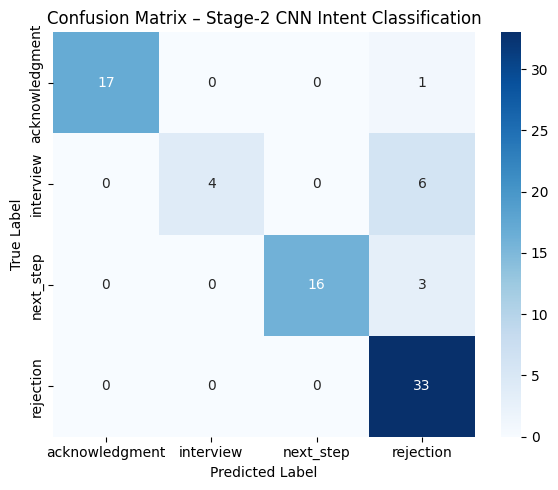

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Class names (in correct order)
class_names = le.classes_

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Stage-2 CNN Intent Classification")
plt.tight_layout()
plt.show()


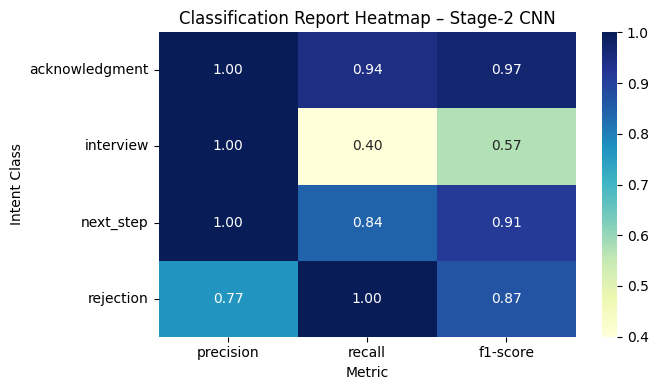

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Generate classification report as dict
report_dict = classification_report(
    y_val,
    y_pred,
    target_names=le.classes_,
    output_dict=True
)

# Convert to DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Keep only useful metrics
report_df = report_df.loc[le.classes_, ["precision", "recall", "f1-score"]]

# Plot heatmap
plt.figure(figsize=(7, 4))
sns.heatmap(
    report_df,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Classification Report Heatmap – Stage-2 CNN")
plt.ylabel("Intent Class")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()


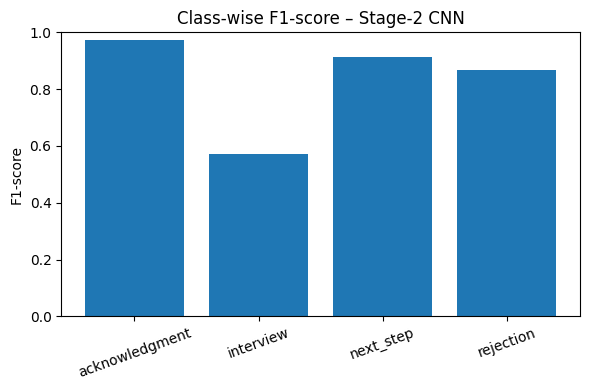

In [27]:
# Plot class-wise F1-score
plt.figure(figsize=(6, 4))
plt.bar(
    report_df.index,
    report_df["f1-score"]
)

plt.ylim(0, 1)
plt.ylabel("F1-score")
plt.title("Class-wise F1-score – Stage-2 CNN")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


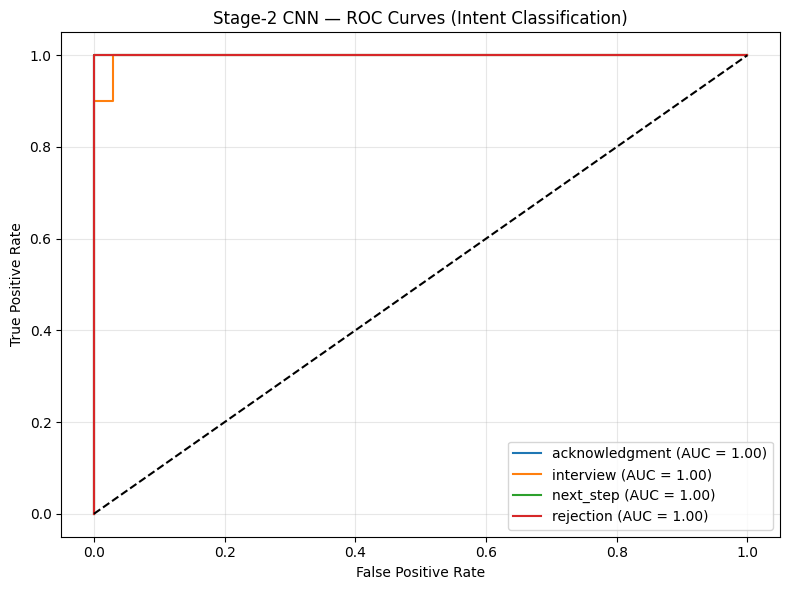

In [28]:
# ---------------- ROC CURVE (STAGE-2 CNN) ----------------
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability scores
y_probs = cnn_model.predict(X_val)

# Number of classes
num_classes = y_probs.shape[1]

# Binarize true labels
y_val_bin = label_binarize(
    y_val,
    classes=list(range(num_classes))
)

plt.figure(figsize=(8, 6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        label=f"{le.classes_[i]} (AUC = {roc_auc:.2f})"
    )

# Random baseline
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Stage-2 CNN — ROC Curves (Intent Classification)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [29]:
macro_auc = np.mean([
    auc(*roc_curve(y_val_bin[:, i], y_probs[:, i])[:2])
    for i in range(num_classes)
])

print("Stage-2 CNN Macro-AUC:", round(macro_auc, 4))


Stage-2 CNN Macro-AUC: 0.9993


In [30]:
# ======================================
# STAGE-2B: XLM-R INTENT CLASSIFIER (OOM-SAFE)
# ======================================

import pandas as pd
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score
from transformers import (
    XLMRobertaTokenizer,
    XLMRobertaForSequenceClassification,
    Trainer,
    TrainingArguments
)
import joblib

# ---------------- CLEAR GPU MEMORY ----------------
torch.cuda.empty_cache()

# ---------------- LOAD DATA ----------------
df = pd.read_csv("stage2_final_clean.csv")

df = df[["preprocessed_text", "intent_label"]].rename(
    columns={
        "preprocessed_text": "text",
        "intent_label": "intent"
    }
).dropna()

print("Loaded Stage-2 data shape:", df.shape)
print(df["intent"].value_counts())

# ---------------- LABEL ENCODING ----------------
le = LabelEncoder()
df["label"] = le.fit_transform(df["intent"])
num_labels = len(le.classes_)

joblib.dump(le, "label_encoder_stage2.joblib")

# ---------------- SPLIT ----------------
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

# ---------------- TOKENIZER ----------------
tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")

MAX_LEN = 128   # 🔴 reduced from 256

class IntentDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts.tolist(),
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN
        )
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_ds = IntentDataset(train_df["text"], train_df["label"])
val_ds   = IntentDataset(val_df["text"], val_df["label"])

# ---------------- MODEL ----------------
model = XLMRobertaForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=num_labels
)

# Enable memory-saving features
model.gradient_checkpointing_enable()

model.config.id2label = {i: l for i, l in enumerate(le.classes_)}
model.config.label2id = {l: i for i, l in enumerate(le.classes_)}

# ---------------- TRAINING ARGS ----------------
training_args = TrainingArguments(
    output_dir="./xlmr_stage2",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=25,
    report_to="none",
    no_cuda=True   # 🔴 FORCE CPU
)


# ---------------- TRAINER ----------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds
)

# ---------------- TRAIN ----------------
trainer.train()

# ---------------- EVALUATION ----------------
preds = trainer.predict(val_ds)
y_pred = preds.predictions.argmax(axis=1)

print("\n=== STAGE-2 XLM-R CLASSIFICATION REPORT ===")
print(classification_report(val_df["label"], y_pred, target_names=le.classes_))

# ---------------- SAVE MODEL ----------------
trainer.save_model("./xlmr_stage2")
tokenizer.save_pretrained("./xlmr_stage2")

print("✅ Stage-2 XLM-R model saved successfully.")


Loaded Stage-2 data shape: (400, 2)
intent
rejection         165
next_step          94
acknowledgment     90
interview          51
Name: count, dtype: int64


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1636: FutureWarning: using `no_cuda` is deprecated and will be removed in version 5.0 of 🤗 Transformers. Use `use_cpu` instead
  warnings.warn(


Step,Training Loss
25,1.297100
50,1.324400
75,1.145100
100,1.023000
125,0.792700
150,0.470200
175,0.440400
200,0.350500
225,0.271500
250,0.146400



=== STAGE-2 XLM-R CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

acknowledgment       1.00      1.00      1.00        18
     interview       1.00      0.90      0.95        10
     next_step       0.95      1.00      0.97        19
     rejection       1.00      1.00      1.00        33

      accuracy                           0.99        80
     macro avg       0.99      0.97      0.98        80
  weighted avg       0.99      0.99      0.99        80

✅ Stage-2 XLM-R model saved successfully.


In [31]:
# XLM-R predictions
y_true_xlmr = val_df["label"].values
y_pred_xlmr = y_pred  # from trainer.predict(...)


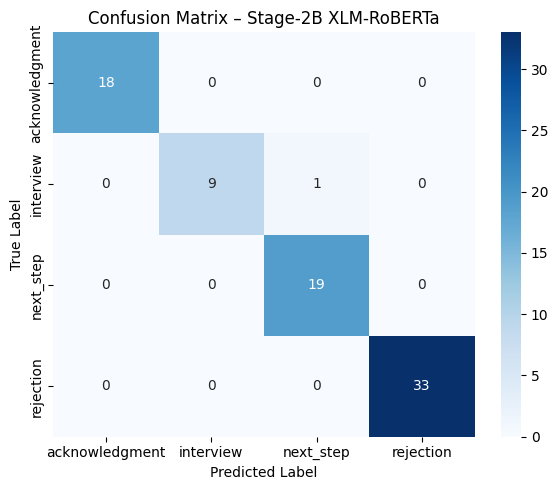

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# True and predicted labels
y_true = val_df["label"].values
y_pred = y_pred   # already computed from trainer

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Stage-2B XLM-RoBERTa")
plt.tight_layout()
plt.show()


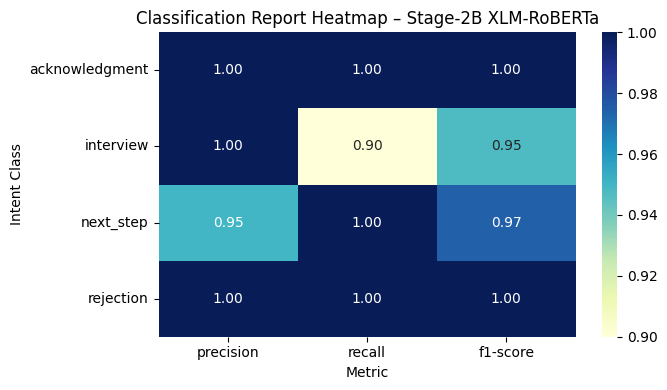

In [33]:
import pandas as pd
from sklearn.metrics import classification_report

# Generate report as dictionary
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=le.classes_,
    output_dict=True,
    zero_division=0   # avoids warnings
)

# Convert to DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Keep only class rows and metrics
report_df = report_df.loc[le.classes_, ["precision", "recall", "f1-score"]]

# Plot heatmap
plt.figure(figsize=(7, 4))
sns.heatmap(
    report_df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Classification Report Heatmap – Stage-2B XLM-RoBERTa")
plt.xlabel("Metric")
plt.ylabel("Intent Class")
plt.tight_layout()
plt.show()


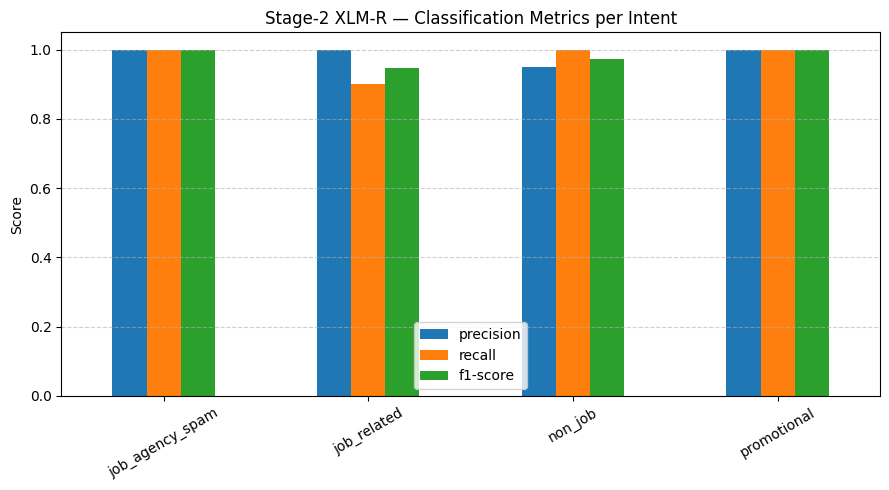

In [34]:
import pandas as pd
from sklearn.metrics import classification_report

# Convert classification report to DataFrame
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=label_names,
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()

metrics = ["precision", "recall", "f1-score"]

df_report.loc[label_names, metrics].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Stage-2 XLM-R — Classification Metrics per Intent")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


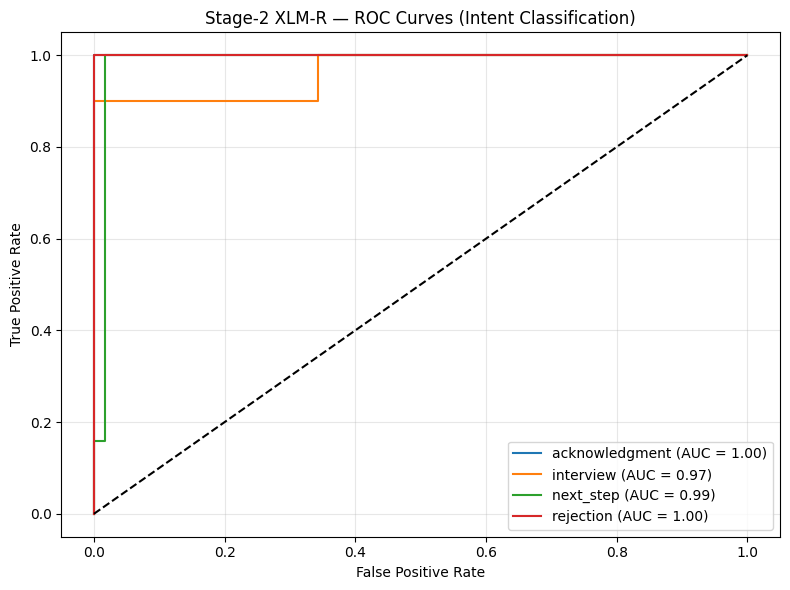

In [35]:
# ================= ROC FIX (STAGE-2 XLM-R) =================
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Re-run prediction ONCE to ensure alignment
preds_output = trainer.predict(val_ds)

logits = preds_output.predictions
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()

# True labels from the SAME dataset
y_true = val_df["label"].values

# Safety check (THIS MUST PASS)
assert len(y_true) == probs.shape[0], (
    f"Length mismatch: y_true={len(y_true)}, probs={probs.shape[0]}"
)

num_classes = probs.shape[1]
label_names = list(le.classes_)

# Binarize labels
y_true_bin = label_binarize(
    y_true,
    classes=list(range(num_classes))
)

# Plot ROC curves
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        label=f"{label_names[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Stage-2 XLM-R — ROC Curves (Intent Classification)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [36]:
# Gmail auth & fetch (Colab-friendly run_console)
from google_auth_oauthlib.flow import InstalledAppFlow
from googleapiclient.discovery import build
from google.auth.transport.requests import Request

SCOPES = ['https://www.googleapis.com/auth/gmail.readonly']
TOKEN_PATH = "/content/token.pickle"
CREDENTIALS_PATH = "/content/credentials.json"  # upload in Colab

def gmail_authenticate(creds_path=CREDENTIALS_PATH, token_path=TOKEN_PATH):
    creds = None
    if os.path.exists(token_path):
        with open(token_path, 'rb') as f:
            creds = pickle.load(f)
    if not creds or not creds.valid:
        if creds and creds.expired and creds.refresh_token:
            creds.refresh(Request())
        else:
            flow = InstalledAppFlow.from_client_secrets_file(creds_path, SCOPES)
            creds = flow.run_console()   # copy-paste auth code for Colab
        with open(token_path, 'wb') as f:
            pickle.dump(creds, f)
    service = build('gmail', 'v1', credentials=creds)
    return service

def fetch_messages(service, max_results=10, query='is:unread'):
    results = service.users().messages().list(userId='me', maxResults=max_results, q=query).execute()
    messages = results.get('messages', [])
    out = []
    for m in messages:
        msg = service.users().messages().get(userId='me', id=m['id'], format='full').execute()
        payload = msg.get('payload', {})
        headers = payload.get('headers', [])
        subject = ''
        sender = ''
        for h in headers:
            if h['name'].lower()=='subject': subject = h['value']
            if h['name'].lower()=='from': sender = h['value']
        body = ""
        if payload.get('parts'):
            for part in payload['parts']:
                if part.get('mimeType') == 'text/plain' and part.get('body', {}).get('data'):
                    body = base64.urlsafe_b64decode(part['body']['data'].encode('ASCII')).decode('utf-8', errors='ignore')
                    break
                if part.get('mimeType') == 'text/html' and part.get('body', {}).get('data'):
                    html = base64.urlsafe_b64decode(part['body']['data'].encode('ASCII')).decode('utf-8', errors='ignore')
                    body = re.sub('<[^<]+?>', '', html)
                    break
        else:
            bd = payload.get('body', {}).get('data')
            if bd:
                body = base64.urlsafe_b64decode(bd.encode('ASCII')).decode('utf-8', errors='ignore')
        out.append({'id': m['id'], 'subject': subject, 'from': sender, 'body': body})
    return out


In [37]:
import os
import re
import pickle
import base64
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
from googleapiclient.discovery import build
from google_auth_oauthlib.flow import Flow
from google.auth.transport.requests import Request
import warnings
warnings.filterwarnings('ignore')

SCOPES = ["https://www.googleapis.com/auth/gmail.readonly"]

def get_credentials():
    creds = None
    if os.path.exists("token.pickle"):
        with open("token.pickle", "rb") as token:
            creds = pickle.load(token)
    if not creds or not creds.valid:
        if creds and creds.expired and creds.refresh_token:
            creds.refresh(Request())
        else:
            flow = Flow.from_client_secrets_file(
                "credentials.json",
                scopes=SCOPES,
                redirect_uri='urn:ietf:wg:oauth:2.0:oob'
            )
            auth_url, _ = flow.authorization_url(prompt='consent', access_type='offline')
            print('Visit this URL to authorize access:')
            print(auth_url)
            code = input('Enter the authorization code: ')
            flow.fetch_token(code=code)
            creds = flow.credentials
        with open("token.pickle", "wb") as token:
            pickle.dump(creds, token)
    return creds

def extract_text_from_message(message):
    payload = message['payload']
    def get_text(part):
        if part.get('mimeType') == 'text/plain':
            data = part['body'].get('data')
            if data:
                return base64.urlsafe_b64decode(data).decode('utf-8', errors='ignore')
        elif part.get('parts'):
            for p in part.get('parts', []):
                text = get_text(p)
                if text:
                    return text
        return None
    text = get_text(payload)
    return text.strip() if text else message.get('snippet', '')

def get_all_messages(service, query=""):
    messages = []
    next_page_token = None
    while True:
        response = service.users().messages().list(
            userId='me',
            q=query,
            maxResults=100,
            pageToken=next_page_token
        ).execute()
        batch = response.get('messages', [])
        messages.extend(batch)
        next_page_token = response.get('nextPageToken')
        if not next_page_token:
            break
    return messages

def process_email(message, service):
    msg = service.users().messages().get(userId='me', id=message['id'], format='full').execute()
    headers = msg['payload']['headers']
    subject = next((h['value'] for h in headers if h['name'].lower() == 'subject'), '(No Subject)')
    sender = next((h['value'] for h in headers if h['name'].lower() == 'from'), '(Unknown Sender)')
    date = next((h['value'] for h in headers if h['name'].lower() == 'date'), '(No Date)')
    text = extract_text_from_message(msg)
    if len(text) > 1500:
        text = text[:1500] + "..."
    return [date, sender, subject, text]


In [38]:
class EmailPreprocessor:
    def __init__(self):
        self.email_pattern = re.compile(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b')
        self.url_pattern = re.compile(r'http[s]?://\S+')
        self.jobmeta_pattern = re.compile(r'view job: url|~[a-z0-9\-]+~', flags=re.IGNORECASE)

    def remove_html_tags(self, text: str) -> str:
        if pd.isna(text):
            return ""
        return BeautifulSoup(text, "html.parser").get_text()

    def normalize_umlauts(self, text: str) -> str:
        if pd.isna(text):
            return ""
        replacements = {'ä':'ae','ö':'oe','ü':'ue','Ä':'Ae','Ö':'Oe','Ü':'Ue','ß':'ss'}
        for k,v in replacements.items():
            text = text.replace(k,v)
        return text

    def clean_text(self, text: str) -> str:
        if pd.isna(text):
            return ""
        text = self.remove_html_tags(text)
        text = self.normalize_umlauts(text)
        text = self.url_pattern.sub(' URL ', text)
        text = self.email_pattern.sub(' EMAIL ', text)
        text = self.jobmeta_pattern.sub(' ', text)
        text = re.sub(r'\s+', ' ', text).strip().lower()
        return text

preprocessor = EmailPreprocessor()


In [39]:
def fetch_and_preprocess_emails(query="after:2025/11/11"):
    creds = get_credentials()
    service = build('gmail', 'v1', credentials=creds)
    messages = get_all_messages(service, query=query)

    dataset = []
    for idx, msg in enumerate(messages):
        try:
            dataset.append(process_email(msg, service))
            if (idx+1) % 50 == 0:
                print(f"Fetched {idx+1}/{len(messages)} emails...")
        except:
            continue

    df = pd.DataFrame(dataset, columns=["Date", "Sender", "Subject", "Email Text"])
    df['email_text'] = df['Subject'].astype(str) + " " + df['Email Text'].astype(str)
    df['preprocessed_text'] = df['email_text'].apply(preprocessor.clean_text)

    # <-- fix for Excel encoding
    df.to_csv("fetched_emails_preprocessed.csv", index=False, encoding='utf-8-sig')

    print(f"✅ Emails fetched and preprocessed: {df.shape}")
    return df

# Run
emails_df = fetch_and_preprocess_emails()


Visit this URL to authorize access:
https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=700764591950-s1itte6fag4g0ndsb1ihiqr6p6ijg1s6.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fgmail.readonly&state=7VmBPUCZApZNhWA1rxva88Qgdh4Lir&prompt=consent&access_type=offline
Enter the authorization code: 4/1ATX87lOSCjd0tzsHwWFpAc6Z-lHprQmRoscRldI2WLmS3GIgOIWvHidts4Y
Fetched 50/426 emails...
Fetched 100/426 emails...
Fetched 150/426 emails...
Fetched 200/426 emails...
Fetched 250/426 emails...
Fetched 300/426 emails...
Fetched 350/426 emails...
Fetched 400/426 emails...
✅ Emails fetched and preprocessed: (426, 6)


In [40]:
# ====== STAGE 1 INFERENCE (CLEAN FINAL VERSION) ======

import numpy as np
import pandas as pd
import torch, joblib
from transformers import pipeline
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

# -----------------------
# Load label encoder
# -----------------------
le = joblib.load("/content/stage1_models/label_encoder_stage1.joblib")
id2label = {i: l for i, l in enumerate(le.classes_)}

VALID_CATEGORIES = {
    "job_related",
    "non_job",
    "promotional",
    "job_agency_spam"
}

# -----------------------
# Texts
# -----------------------
texts = emails_df["preprocessed_text"].fillna("").tolist()

# -----------------------
# CNN prediction
# -----------------------
cnn = load_model("/content/stage1_models/keras_cnn_stage1.h5")

with open("/content/stage1_models/keras_tokenizer.json") as f:
    tok = tokenizer_from_json(f.read())

seq = pad_sequences(tok.texts_to_sequences(texts), maxlen=300)
cnn_probs = cnn.predict(seq, verbose=0)

emails_df["cnn_label"] = [id2label[i] for i in np.argmax(cnn_probs, axis=1)]
emails_df["cnn_score"] = np.max(cnn_probs, axis=1)

# -----------------------
# XLM-R fallback
# -----------------------
pipe = pipeline(
    "text-classification",
    model="/content/stage1_models/xlm_stage1",
    tokenizer="/content/stage1_models/xlm_stage1",
    device=0 if torch.cuda.is_available() else -1
)

xlm_out = pipe(texts, batch_size=8, truncation=True)
emails_df["xlm_label"] = [o["label"] for o in xlm_out]

# -----------------------
# Final decision
# -----------------------
emails_df["category"] = emails_df["cnn_label"]

low_conf = emails_df["cnn_score"] < 0.7
emails_df.loc[low_conf, "category"] = emails_df.loc[low_conf, "xlm_label"]

# -----------------------
# CLEAN INVALID LABELS
# -----------------------
emails_df["category"] = emails_df["category"].where(
    emails_df["category"].isin(VALID_CATEGORIES)
)

# Drop rows with invalid labels
emails_df = emails_df.dropna(subset=["category"])

# -----------------------
# FINAL OUTPUT FILE
# -----------------------
final_df = emails_df[
    ["Sender", "Subject", "preprocessed_text", "category"]
].copy()

output_path = "/content/stage1_final_categories_clean.csv"
final_df.to_csv(output_path, index=False)

print(f"✅ Saved clean file: {output_path}")
print("\nFinal category distribution:")
print(final_df["category"].value_counts())


The tokenizer you are loading from '/content/stage1_models/xlm_stage1' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cuda:0


✅ Saved clean file: /content/stage1_final_categories_clean.csv

Final category distribution:
category
non_job            130
job_agency_spam    117
promotional         49
job_related          9
Name: count, dtype: int64


In [41]:
import pandas as pd

def _norm(x):
    return str(x).lower() if x is not None else ""

def rule_is_job_application(text):
    t = _norm(text)
    keywords = [
        "deine bewerbung", "ihre bewerbung",
        "your application", "application status",
        "absage", "rejection", "leider",
        "interview", "vorstellungsgespräch",
        "we regret", "thank you for applying"
    ]
    return any(k in t for k in keywords)

RECRUITER_SENDERS = [
    "concludis.de", "successfactors", "workday",
    "recruitee", "smartrecruiters", "greenhouse",
    "lever.co", "icims", "kfc.de", "dhl.com",
    "bmwgroup.com"
]

def rule_is_recruiter_sender(sender):
    return any(k in _norm(sender) for k in RECRUITER_SENDERS)


# ---------- Job portals / newsletters ----------
JOB_PORTAL_SENDERS = [
    "sportfive", "jobvector", "stepstone",
    "xing", "linkedin", "indeed",
    "jobagent", "jobalerts", "karriere"
]

def rule_is_job_alert(sender, subject):
    s, sub = _norm(sender), _norm(subject)
    return any(k in s for k in JOB_PORTAL_SENDERS) or \
           any(k in sub for k in ["jobs der", "new job", "job alert", "stellenangebote"])


# ---------- Academic ----------
def rule_is_academic(text):
    t = _norm(text)
    return sum(k in t for k in ["university", "campus", "msc", "bsc", "admission"]) >= 2


# ---------- Commerce ----------
def rule_is_commerce(text):
    t = _norm(text)
    return any(k in t for k in ["order", "delivery", "invoice", "tracking", "payment"])


# ---------- Account ----------
def rule_is_account(text):
    t = _norm(text)
    return any(k in t for k in ["account", "password", "login", "deleted"])


# =========================================================
# FINAL DECISION FUNCTION
# =========================================================
def authenticity(sender, subject, text):
    s, sub, t = _norm(sender), _norm(subject), _norm(text)

    # 1️⃣ Job portals / alerts (must be first)
    if rule_is_job_alert(s, sub):
        return "job_alert"

    # 2️⃣ Academic noise
    if rule_is_academic(t):
        return "academic"

    # 3️⃣ ✅ REAL JOB APPLICATION (OVERRIDE)
    if rule_is_recruiter_sender(s) and (
        rule_is_job_application(sub) or rule_is_job_application(t)
    ):
        return "real_job_application"

    # 4️⃣ Account / security
    if rule_is_account(sub) or rule_is_account(t):
        return "account_notification"

    # 5️⃣ Commerce (LOW priority)
    if rule_is_commerce(t):
        return "commerce"

    return "other"



# =========================================================
# APPLY STAGE 1.5
# =========================================================
stage1_pass = emails_df[emails_df["category"] == "job_related"].copy()

stage1_pass["authenticity"] = stage1_pass.apply(
    lambda r: authenticity(r["Sender"], r["Subject"], r["preprocessed_text"]),
    axis=1
)

stage2_runtime = stage1_pass[
    stage1_pass["authenticity"] == "real_job_application"
].copy()

filtered_out = stage1_pass[
    stage1_pass["authenticity"] != "real_job_application"
].copy()

print("✅ Passed to Stage-2:")
display(stage2_runtime[["Sender", "Subject"]])

print("\n❌ Filtered at Stage-1.5:")
display(filtered_out[["Sender", "Subject", "authenticity"]])

print("\n📊 Breakdown:")
display(filtered_out["authenticity"].value_counts())


✅ Passed to Stage-2:


,Sender,Subject
332,Recruiting DLR <system@successfactors.eu>,Deine Bewerbung beim DLR (2777) - Student/in (...
401,Octopus Energy <no-reply@hire.lever.co>,🐙 Your application at Octopus Energy Germany 🐙



❌ Filtered at Stage-1.5:


,Sender,Subject,authenticity
14,Vivek Ammanabrolu <vivekammanabrolu458@gmail.com>,Re: Studentisches Wohnen - fehlende Unterlagen...,commerce
117,SPORTFIVE Eventjobs <events@jobs.sportfive.com>,Jobs der nächsten Woche,job_alert
118,Christian Seifert <seifechr@b-tu.de>,Re: Subject: Application – Student / Research ...,other
172,"""Emma Krüger"" <e.krueger@nollservice.com>",Paketsortierer Flughafen Berlin,commerce
216,SBI Cashback Card <reshma@techslash.com>,vivekammanabrolu458 - Submit Your Application ...,other
244,Nestle <sofie@snapquill.com>,Sie haben (1) Nachricht vom Personalvermittler,other
336,Thomas Elfert <thomas.elfert@b-tu.de>,BTU Career Events in December & January – For ...,other



📊 Breakdown:


,count
authenticity,
other,4
commerce,2
job_alert,1


In [42]:
# ====== STAGE 2 INFERENCE ======
le2 = joblib.load("label_encoder_stage2.joblib")

pipe2 = pipeline(
    "text-classification",
    model="./xlmr_stage2",
    tokenizer="./xlmr_stage2",
    device=0 if torch.cuda.is_available() else -1
)

texts2 = stage2_runtime["preprocessed_text"].tolist()
out2 = pipe2(texts2, batch_size=8, truncation=True)

stage2_runtime["predicted_intent"] = [o["label"] for o in out2]

display(stage2_runtime[["Sender", "Subject","predicted_intent"]].head())


The tokenizer you are loading from './xlmr_stage2' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cuda:0


,Sender,Subject,predicted_intent
332,Recruiting DLR <system@successfactors.eu>,Deine Bewerbung beim DLR (2777) - Student/in (...,rejection
401,Octopus Energy <no-reply@hire.lever.co>,🐙 Your application at Octopus Energy Germany 🐙,rejection


In [43]:
# ====== STAGE 2 INFERENCE + SAVE RESULT ======

import joblib
import torch
import pandas as pd
from transformers import pipeline
from google.colab import files

# Load label encoder (optional, kept for consistency)
le2 = joblib.load("label_encoder_stage2.joblib")

# Load XLM-R Stage-2 model
pipe2 = pipeline(
    "text-classification",
    model="./xlmr_stage2",
    tokenizer="./xlmr_stage2",
    device=0 if torch.cuda.is_available() else -1
)

# Run inference
texts2 = stage2_runtime["preprocessed_text"].tolist()
out2 = pipe2(texts2, batch_size=8, truncation=True)

# Attach predictions
stage2_runtime["predicted_intent"] = [o["label"] for o in out2]

# Keep ONLY required columns
final_stage2_df = stage2_runtime[
    ["Sender", "Subject", "predicted_intent"]
].copy()

# Save file to Colab runtime
output_path = "/content/stage2_predictions.csv"
final_stage2_df.to_csv(output_path, index=False)

print(f"✅ Saved file at: {output_path}")
print(final_stage2_df["predicted_intent"].value_counts())

# 🔽 Trigger download to your system
files.download(output_path)

The tokenizer you are loading from './xlmr_stage2' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cuda:0


✅ Saved file at: /content/stage2_predictions.csv
predicted_intent
rejection    2
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
from transformers import pipeline
import torch, joblib
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

DATE_QUERY = "after:2025/8/11"   # 🔁 change this anytime

print(f"📅 Fetching emails with query: {DATE_QUERY}")

emails_df = fetch_and_preprocess_emails(query=DATE_QUERY)
print("📨 Emails fetched:", len(emails_df))




📅 Fetching emails with query: after:2025/8/11
Fetched 50/801 emails...
Fetched 100/801 emails...
Fetched 150/801 emails...
Fetched 200/801 emails...
Fetched 250/801 emails...
Fetched 300/801 emails...
Fetched 350/801 emails...
Fetched 400/801 emails...
Fetched 450/801 emails...
Fetched 500/801 emails...
Fetched 550/801 emails...
Fetched 600/801 emails...
Fetched 650/801 emails...
Fetched 700/801 emails...
Fetched 750/801 emails...
Fetched 800/801 emails...
✅ Emails fetched and preprocessed: (801, 6)
📨 Emails fetched: 801


In [45]:
# =========================================================
# CONFIG (ONLY FOR FILE NAMING)
# =========================================================
DATE_QUERY = "after:2025/8/11"   # used ONLY for filenames
date_tag = DATE_QUERY.replace("after:", "").replace("/", "-")

import gc, torch, joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from transformers import pipeline
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

print(f"📦 Running inference on already-fetched emails")
print("📨 Emails available:", len(emails_df))


# =========================================================
# STAGE 1 — CNN (GPU)
# =========================================================
le = joblib.load("/content/stage1_models/label_encoder_stage1.joblib")
id2label = dict(enumerate(le.classes_))

cnn = load_model("/content/stage1_models/keras_cnn_stage1.h5")
with open("/content/stage1_models/keras_tokenizer.json") as f:
    tok = tokenizer_from_json(f.read())

seq = pad_sequences(
    tok.texts_to_sequences(emails_df["preprocessed_text"].fillna("")),
    maxlen=300
)

cnn_probs = cnn.predict(seq, verbose=0)
emails_df["cnn_label"] = [id2label[i] for i in np.argmax(cnn_probs, axis=1)]
emails_df["cnn_score"] = np.max(cnn_probs, axis=1)

# 🔥 FREE GPU MEMORY (CRITICAL)
del cnn
tf.keras.backend.clear_session()
gc.collect()


# =========================================================
# STAGE 1 — XLM-R FALLBACK (CPU ONLY → avoids OOM)
# =========================================================
pipe_stage1 = pipeline(
    "text-classification",
    model="/content/stage1_models/xlm_stage1",
    tokenizer="/content/stage1_models/xlm_stage1",
    device=-1
)

low_conf = emails_df["cnn_score"] < 0.7
emails_df["category"] = emails_df["cnn_label"]

if low_conf.any():
    fallback_texts = emails_df.loc[low_conf, "preprocessed_text"].tolist()
    fallback_preds = pipe_stage1(fallback_texts, batch_size=4, truncation=True)
    emails_df.loc[low_conf, "category"] = [p["label"] for p in fallback_preds]

# Save Stage-1 output
stage1_path = f"/content/stage1_results_{date_tag}.csv"
emails_df[["Date", "Sender", "Subject", "category"]].to_csv(stage1_path, index=False)
print(f"✅ Stage-1 saved → {stage1_path}")


# =========================================================
# STAGE 1.5 — AUTHENTICITY FILTER
# =========================================================
def _norm(x): return str(x).lower() if x is not None else ""

def authenticity(sender, subject, text):
    s = _norm(sender)
    sub = _norm(subject)
    t = _norm(text)

    # HARD JOB APPLICATION OVERRIDE
    if any(k in (s + sub + t) for k in [
        "bewerbung", "your application", "ihre bewerbung",
        "interview", "rejection", "leider"
    ]):
        return "real_job_application"

    # Job alerts / newsletters
    if any(k in s for k in ["jobvector", "stepstone", "xing", "linkedin", "jobagent"]):
        return "job_alert"

    # Commerce
    if any(k in t for k in ["order", "delivery", "invoice", "tracking"]):
        return "commerce"

    # Account / security
    if any(k in t for k in ["account", "password", "login", "deleted"]):
        return "account_notification"

    return "real_job_application"


stage1_pass = emails_df[emails_df["category"] == "job_related"].copy()
stage1_pass["authenticity"] = stage1_pass.apply(
    lambda r: authenticity(r["Sender"], r["Subject"], r["preprocessed_text"]),
    axis=1
)

stage2_runtime = stage1_pass[
    stage1_pass["authenticity"] == "real_job_application"
].copy()

filtered_out = stage1_pass[
    stage1_pass["authenticity"] != "real_job_application"
].copy()

# Save Stage-1.5 results
stage15_pass_path = f"/content/stage1_5_passed_{date_tag}.csv"
stage15_fail_path = f"/content/stage1_5_filtered_{date_tag}.csv"

stage2_runtime.to_csv(stage15_pass_path, index=False)
filtered_out.to_csv(stage15_fail_path, index=False)

print(f"✅ Stage-1.5 passed → {stage15_pass_path}")
print(f"❌ Stage-1.5 filtered → {stage15_fail_path}")


# =========================================================
# STAGE 2 — INTENT CLASSIFICATION (GPU SAFE)
# =========================================================
torch.cuda.empty_cache()

pipe_stage2 = pipeline(
    "text-classification",
    model="./xlmr_stage2",
    tokenizer="./xlmr_stage2",
    device=0 if torch.cuda.is_available() else -1
)

texts2 = stage2_runtime["preprocessed_text"].tolist()
out2 = pipe_stage2(texts2, batch_size=8, truncation=True)

stage2_runtime["predicted_intent"] = [o["label"] for o in out2]

final_path = f"/content/stage2_results_{date_tag}.csv"
stage2_runtime[["Date", "Sender", "Subject", "predicted_intent"]].to_csv(
    final_path, index=False
)

print(f"🎯 Stage-2 saved → {final_path}")
print(stage2_runtime["predicted_intent"].value_counts())


📦 Running inference on already-fetched emails
📨 Emails available: 801


The tokenizer you are loading from '/content/stage1_models/xlm_stage1' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cpu


✅ Stage-1 saved → /content/stage1_results_2025-8-11.csv
✅ Stage-1.5 passed → /content/stage1_5_passed_2025-8-11.csv
❌ Stage-1.5 filtered → /content/stage1_5_filtered_2025-8-11.csv


The tokenizer you are loading from './xlmr_stage2' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cuda:0


🎯 Stage-2 saved → /content/stage2_results_2025-8-11.csv
predicted_intent
next_step         99
rejection         31
acknowledgment    24
Name: count, dtype: int64


In [46]:
# =========================================================
# INSPECT RESULTS — ALL STAGES (HEAD)
# =========================================================

print("\n==============================")
print("📌 STAGE 0 — RAW FETCHED EMAILS")
print("==============================")
display(
    emails_df[["Date", "Sender", "Subject", "preprocessed_text"]].head(5)
)


print("\n==============================")
print("📌 STAGE 1 — CATEGORY CLASSIFICATION")
print("==============================")
display(
    emails_df[["Date", "Sender", "Subject", "category"]].head(5)
)

print("\nStage-1 category distribution:")
display(emails_df["category"].value_counts())


print("\n==============================")
print("📌 STAGE 1.5 — AUTHENTICITY FILTER (PASSED)")
print("==============================")
display(
    stage2_runtime[["Date", "Sender", "Subject", "authenticity"]].head(5)
)

print("\n==============================")
print("📌 STAGE 1.5 — FILTERED OUT (WITH REASONS)")
print("==============================")
display(
    filtered_out[["Date", "Sender", "Subject", "authenticity"]].head(5)
)

print("\nStage-1.5 filtering breakdown:")
display(filtered_out["authenticity"].value_counts())


print("\n==============================")
print("📌 STAGE 2 — FINAL INTENT CLASSIFICATION")
print("==============================")
display(
    stage2_runtime[["Date", "Sender", "Subject", "predicted_intent"]].head(5)
)

print("\nStage-2 intent distribution:")
display(stage2_runtime["predicted_intent"].value_counts())



📌 STAGE 0 — RAW FETCHED EMAILS


,Date,Sender,Subject,preprocessed_text
0,"Thu, 08 Jan 2026 13:48:06 GMT",Google <no-reply@accounts.google.com>,Security alert,security alert [image: google] a new sign-in o...
1,"Thu, 08 Jan 2026 13:29:29 GMT",Google <no-reply@accounts.google.com>,2-Step Verification turned on,2-step verification turned on [image: google] ...
2,"Thu, 8 Jan 2026 18:52:45 +0530 (IST)",Avanse Finance <noreply@avanse.com>,Update for LAN HYDEE00951370,"update for lan hydee00951370 dear customer, th..."
3,"Thu, 08 Jan 2026 13:15:17 GMT",Google <no-reply@accounts.google.com>,Security alert,security alert [image: google] a new sign-in o...
4,"Thu, 08 Jan 2026 18:21:24 +0530",Maharaja Club <members@maharajaclub.airindia.com>,Introducing Jupiter - Our new Points Conversio...,introducing jupiter - our new points conversio...



📌 STAGE 1 — CATEGORY CLASSIFICATION


,Date,Sender,Subject,category
0,"Thu, 08 Jan 2026 13:48:06 GMT",Google <no-reply@accounts.google.com>,Security alert,non_job
1,"Thu, 08 Jan 2026 13:29:29 GMT",Google <no-reply@accounts.google.com>,2-Step Verification turned on,non_job
2,"Thu, 8 Jan 2026 18:52:45 +0530 (IST)",Avanse Finance <noreply@avanse.com>,Update for LAN HYDEE00951370,non_job
3,"Thu, 08 Jan 2026 13:15:17 GMT",Google <no-reply@accounts.google.com>,Security alert,non_job
4,"Thu, 08 Jan 2026 18:21:24 +0530",Maharaja Club <members@maharajaclub.airindia.com>,Introducing Jupiter - Our new Points Conversio...,promotional



Stage-1 category distribution:


...

,count
authenticity,



📌 STAGE 2 — FINAL INTENT CLASSIFICATION


,Date,Sender,Subject,predicted_intent
14,"Thu, 8 Jan 2026 11:55:42 +0100",Vivek Ammanabrolu <vivekammanabrolu458@gmail.com>,Re: Studentisches Wohnen - fehlende Unterlagen...,rejection
117,"Fri, 2 Jan 2026 15:33:11 +0000",SPORTFIVE Eventjobs <events@jobs.sportfive.com>,Jobs der nächsten Woche,next_step
118,"Fri, 02 Jan 2026 14:39:31 +0100",Christian Seifert <seifechr@b-tu.de>,Re: Subject: Application – Student / Research ...,rejection
172,"Fri, 12 Dec 2025 12:28:06 +0000","""Emma Krüger"" <e.krueger@nollservice.com>",Paketsortierer Flughafen Berlin,next_step
216,"Tue, 2 Dec 2025 03:21:31 +0000",SBI Cashback Card <reshma@techslash.com>,vivekammanabrolu458 - Submit Your Application ...,acknowledgment



Stage-2 intent distribution:


,count
predicted_intent,
next_step,99
rejection,31
acknowledgment,24


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


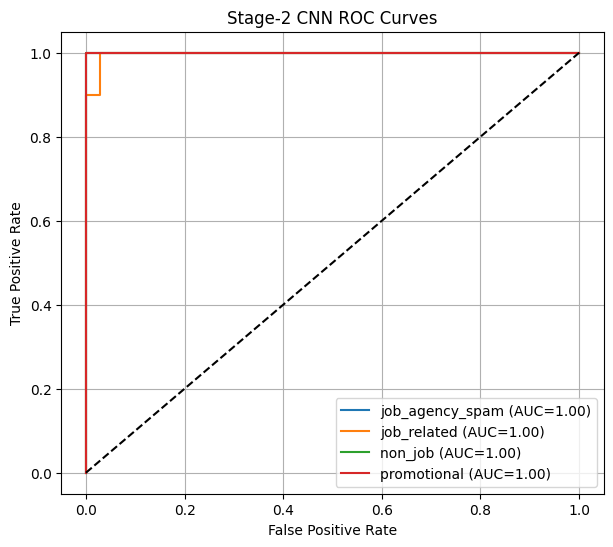

In [47]:
cnn_probs_stage2 = cnn_model.predict(X_val)

y_true_stage2 = y_val
num_classes = cnn_probs_stage2.shape[1]
label_names_stage2 = le.classes_

y_bin = label_binarize(y_true_stage2, classes=range(num_classes))

plt.figure(figsize=(7,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], cnn_probs_stage2[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label_names_stage2[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Stage-2 CNN ROC Curves")
plt.legend()
plt.grid(True)
plt.show()


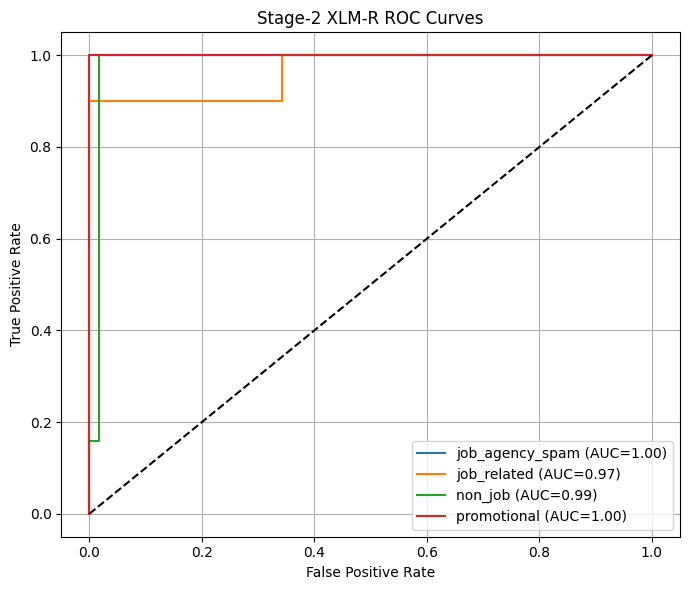

In [48]:
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Get predictions
preds = trainer.predict(val_ds)
xlm_logits_stage2 = preds.predictions

# Convert logits → probabilities
xlm_probs_stage2 = torch.softmax(
    torch.tensor(xlm_logits_stage2),
    dim=1
).numpy()

num_classes = xlm_probs_stage2.shape[1]
label_names_stage2 = le.classes_

# Binarize labels
y_bin = label_binarize(
    val_df["label"],
    classes=range(num_classes)
)

# Plot ROC curves
plt.figure(figsize=(7,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], xlm_probs_stage2[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        label=f"{label_names_stage2[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Stage-2 XLM-R ROC Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
